In [1]:
import sys
import os
import netCDF4
sys.path.append(os.path.abspath('../scripts'))
from visualization import PhenologyVisualization
from functions import datenum_to_datetime, grab_plotting_variables
import functions
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd
from csaps import csaps

In [2]:
lakeid = 310
i , j = 16, 57

In [3]:
# version 3.1
pc_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\phycocyanin\\{lakeid}.nc"
pc_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\phycocyanin\\{lakeid}.nc"

chl_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\chla\\{lakeid}.nc"
chl_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\chla\\{lakeid}.nc"

In [4]:
cci_file = r"C:\Users\schelian\Downloads\lakes_cci_v2.1.0_shp\shapefile\lakescci_v2.1.0_data-availability.shp"
PhenologyVisualization.set_shapefile_path(cci_file)

In [5]:
# load classes
phyco_v3 = PhenologyVisualization(pc_extract_path_v3, pc_phenology_path_v3)
chla_v3 = PhenologyVisualization(chl_extract_path_v3, chl_phenology_path_v3)

In [6]:
%matplotlib inline

## Make a legend

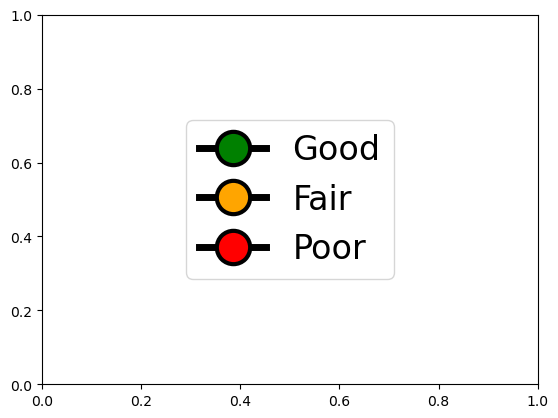

In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_kwargs = {'color':'k','marker':'o', 'markersize':24,'linewidth':5,'mew':3}
legend_elements = [Line2D([0], [0], label='Good', markerfacecolor='green', **legend_kwargs),
                   Line2D([0], [0], label='Fair', markerfacecolor='orange', **legend_kwargs),
                   Line2D([0], [0], label='Poor', markerfacecolor='red', **legend_kwargs),]

# Create the figure
fig, ax = plt.subplots()
ax.legend(handles=legend_elements, loc='center',fontsize=24)

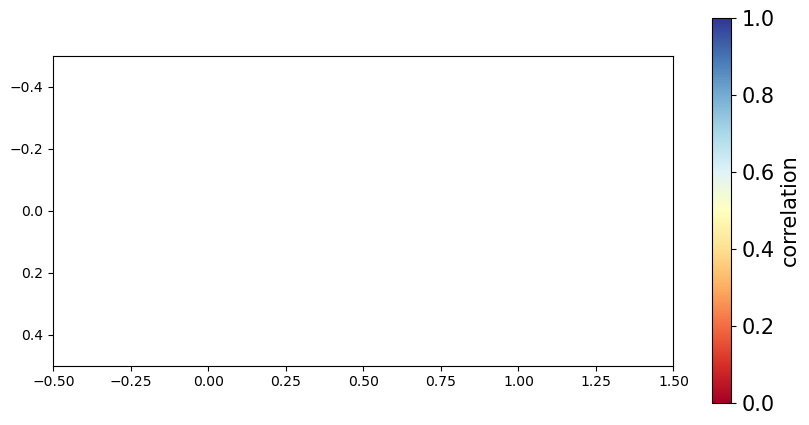

In [8]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

img = plt.imshow(np.array([[0,1]]),cmap='RdYlBu')
img.set_visible(False)
cbar = plt.colorbar(orientation='vertical')
cbar.set_label( label='correlation',size=15)
cbar.ax.tick_params(labelsize=15)

In [11]:

plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

## Standard times series plots

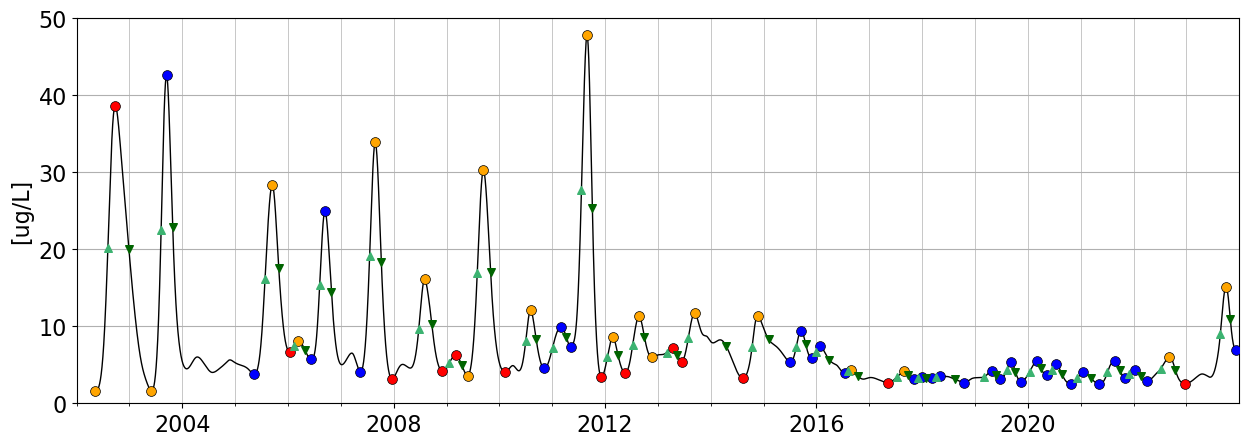

In [13]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(16,57, ax, aggregation=False,start=0, end= 9999)
ax.collections[0].set(color = 'grey')
ax.collections[0].set_sizes([0])
# chla_v3.single_plot(155,306, ax, aggregation=False, start=2003,end= 2012)
# ax.collections[-5].set(color = 'orangered',sizes=[30])
for txt in ax.texts:
    txt.remove()
ax.get_legend().remove()
# ax.set_xlim(pd.to_datetime("25-03-2003", format= "%d-%m-%Y"), pd.to_datetime("01-04-2003", format= "%d-%m-%Y"))
ax.set_ylim(0,50)
for p in ax.patches:
    p.remove()
ax.set_title("")
ax.grid()
ax.grid()


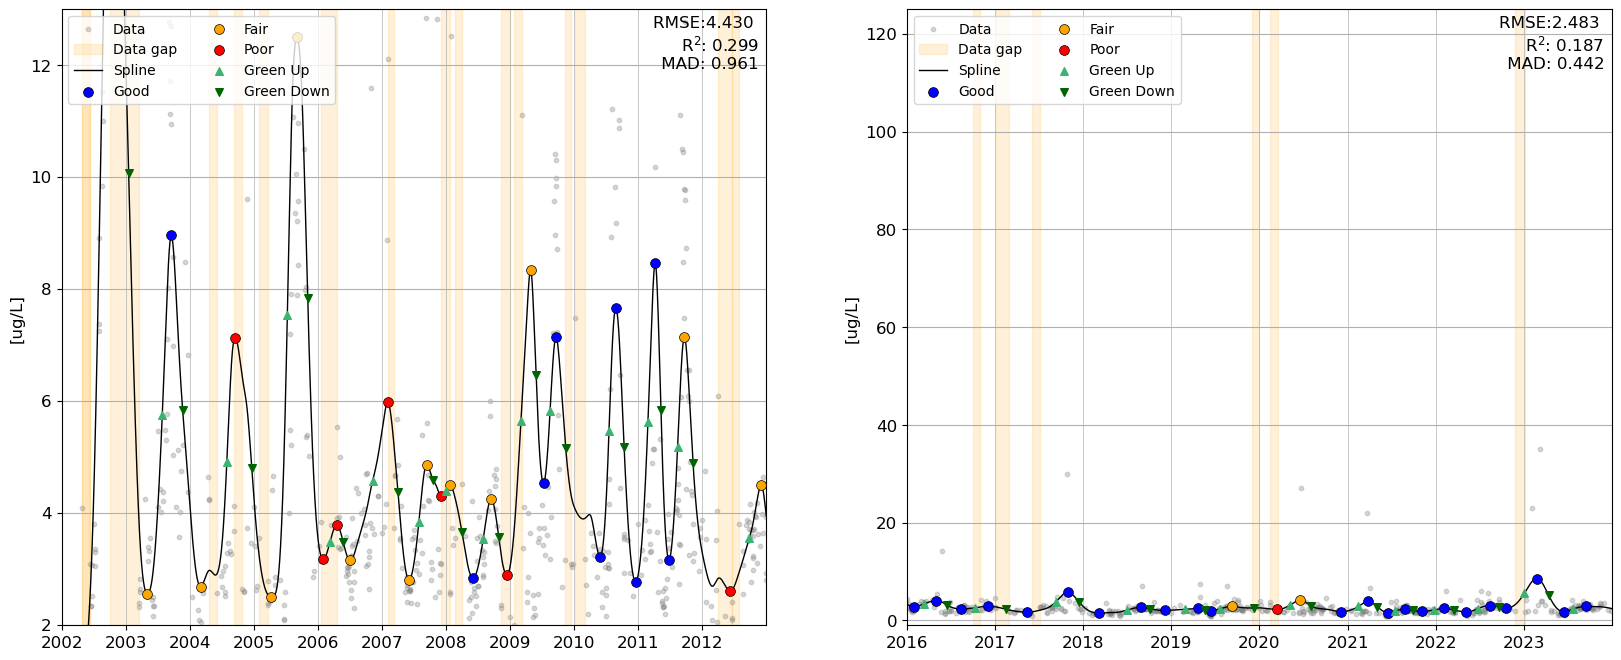

In [11]:

fig, axs = plt.subplots(1,2, figsize = (20,8))

chla_v3.split_plot(ax0 = axs[0], ax1=axs[1],latitude_idx = i,longitude_idx = j, aggregation=False,end0 = 2012,start1 = 2016)
axs[0].set_title("")
axs[1].set_title("")
# axs[0].set_ylim(0,2)
axs[1].set_ylim(-1,125)


axs[0].texts[0].set_fontsize(12)
axs[1].texts[0].set_fontsize(12)


c:\Users\schelian\cci-cyano-production\scripts\visualization.py:1456: UserWarning: You passed a edgecolor/edgecolors ('green') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


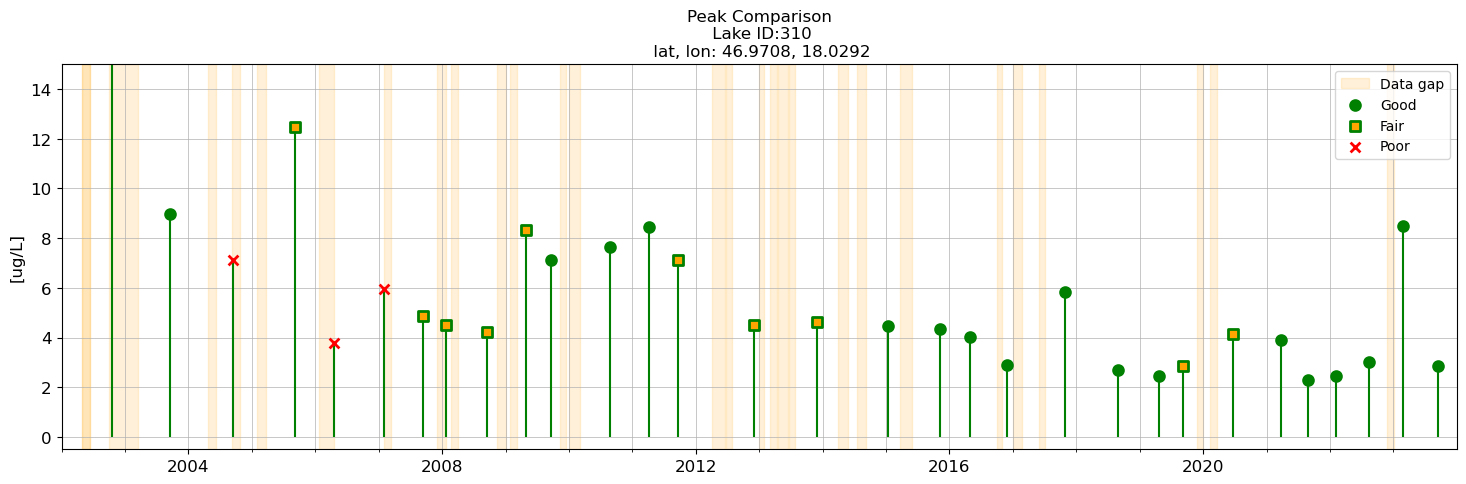

In [12]:
fig, ax = plt.subplots(1,1,figsize=(18,5))

chla_v3.extrema_plot(i,j,ax,background_pts=False)
plt.ylim(top =15)
plt.legend()

## Heatmaps

## Lake KDEs

             primary      qa_column      secondary
count  204210.000000  204210.000000  204210.000000
mean     2012.856153       0.190236    2012.985492
std         6.853866       0.392488       6.843223
min      2002.147000       0.000000    2002.169000
25%      2006.270000       0.000000    2006.306250
50%      2011.132000       0.000000    2011.260000
75%      2019.197000       0.000000    2019.246000
max      2023.323000       1.000000    2023.340000
             primary  qa_column      secondary
count  165362.000000   165362.0  165362.000000
mean     2012.943379        0.0    2013.071885
std         7.091172        0.0       7.078208
min      2002.147000        0.0    2002.169000
25%      2006.147000        0.0    2006.218000
50%      2010.226000        0.0    2010.284000
75%      2020.026000        0.0    2020.111000
max      2023.323000        0.0    2023.340000
            primary  qa_column     secondary
count  38848.000000    38848.0  38848.000000
mean    2012.484863        1

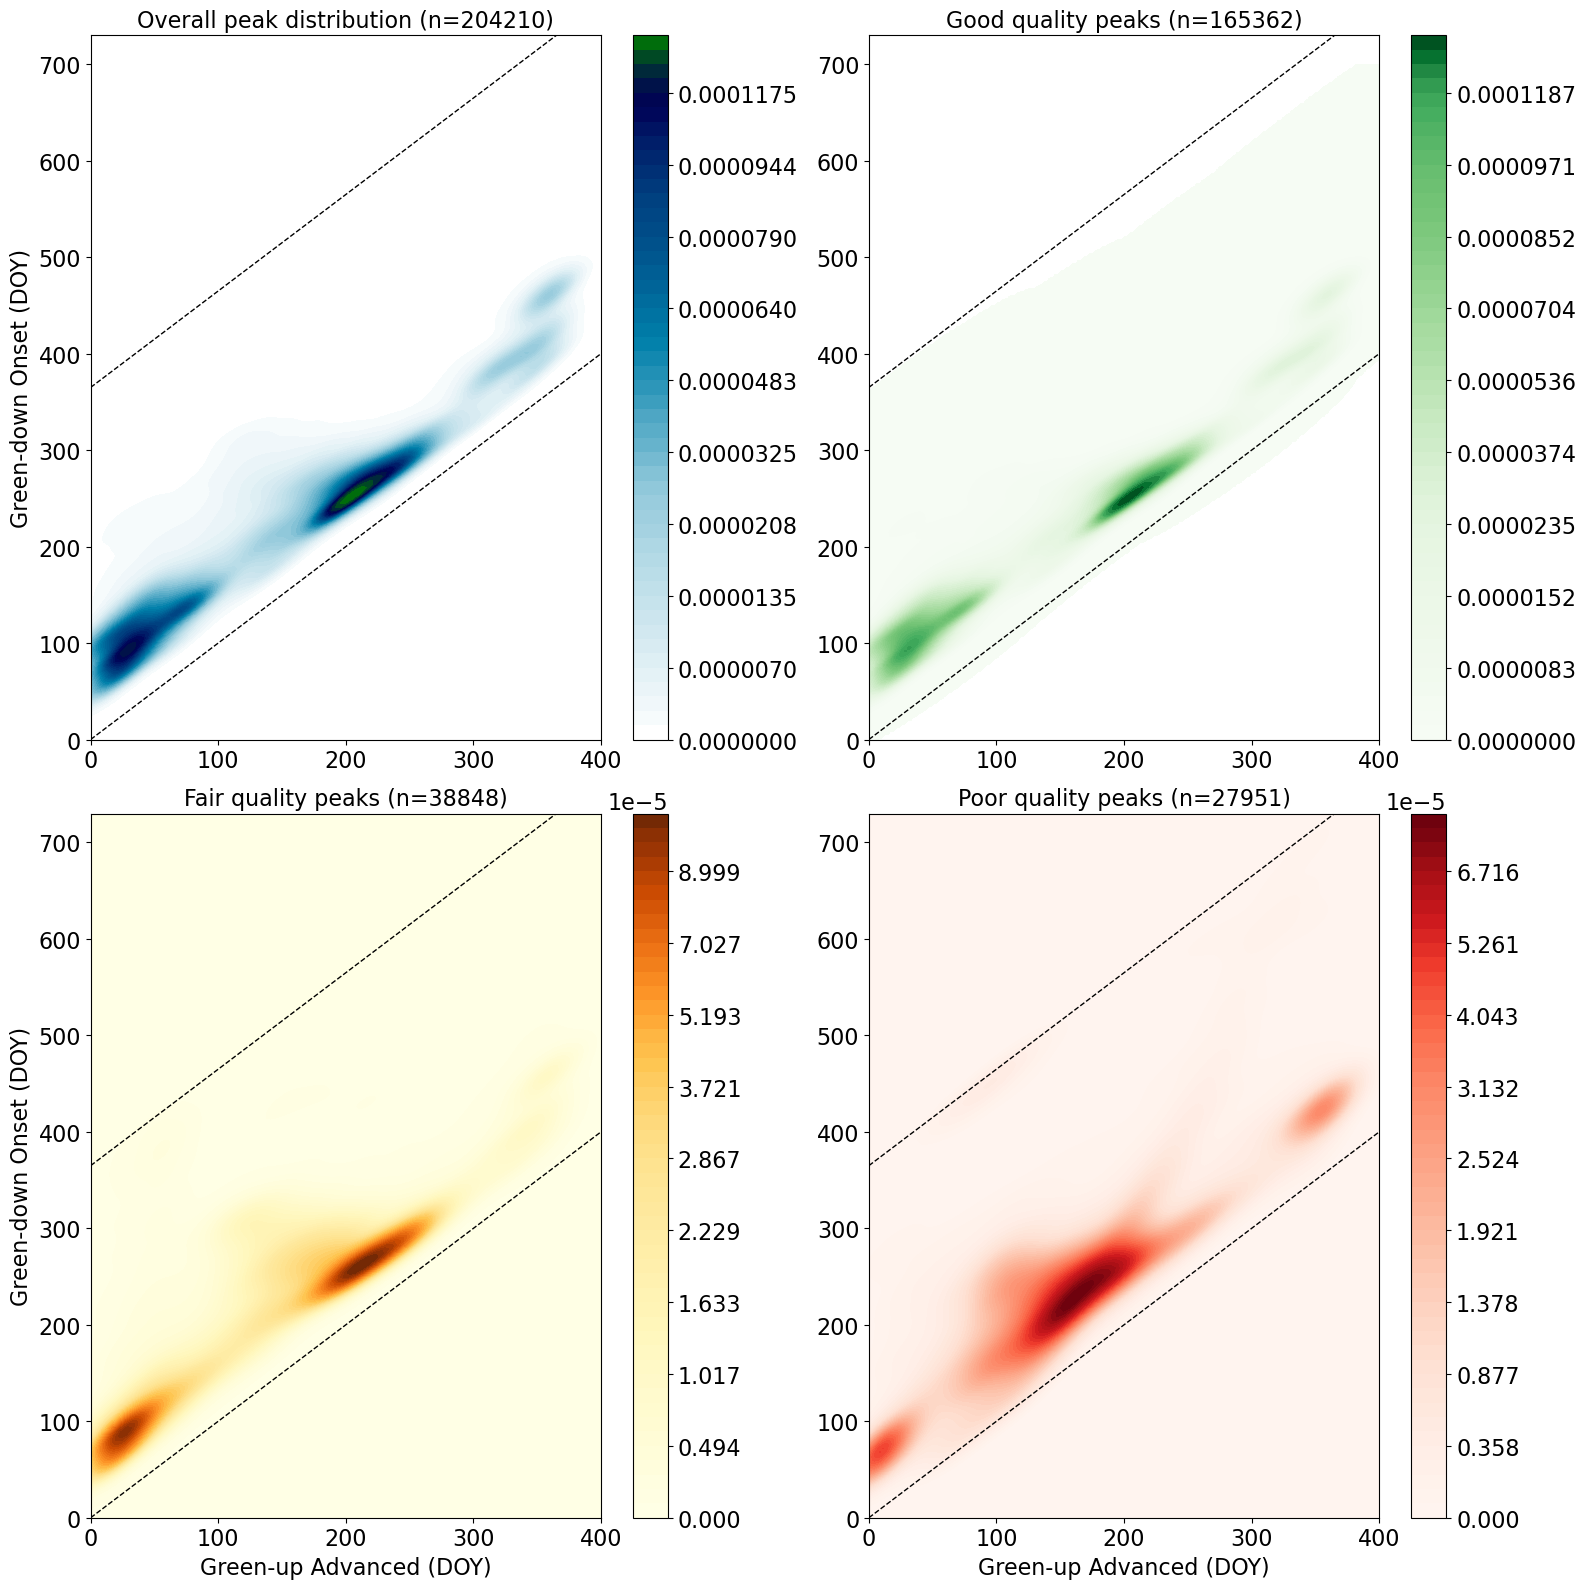

In [49]:
%matplotlib inline
shared_top_level =1
shared_kwargs = {'cmap':'ocean_r'}
fig, ax = plt.subplots(2,2,figsize= (16,16))

ax0 = chla_v3.lake_bloom_kde(ax[0,0], qa_value = {0,1},top_level=shared_top_level,kde_kwargs = {'cmap':'ocean_r'})
ax1 = chla_v3.lake_bloom_kde(ax[0,1], qa_value = {0},top_level=shared_top_level,kde_kwargs = {'cmap':'Greens'})
ax2 = chla_v3.lake_bloom_kde(ax[1,0], qa_value = {1}, top_level=shared_top_level,kde_kwargs = {'cmap':'YlOrBr'})
ax3 = chla_v3.lake_bloom_kde(ax[1,1], qa_value = {2},top_level=shared_top_level,kde_kwargs = {'cmap':'Reds'})

ax1.set_ylabel('')
ax3.set_ylabel('')
ax0.set_xlabel('')
ax1.set_xlabel('')

ax0.set_title('Overall peak distribution (n=204210)',fontsize=16)
ax1.set_title('Good quality peaks (n=165362)',fontsize=16)
ax2.set_title('Fair quality peaks (n=38848)',fontsize=16)
ax3.set_title('Poor quality peaks (n=27951)',fontsize=16)
# ax0.collections[0].colorbar.remove()
# ax1.collections[0].colorbar.remove()
# scale = 22*512
# ax2.collections[0].colorbar.remove()
# cbar.formatter = lambda x, pos: f"{x*scale:.2e}"
# cbar.update_ticks()
# ax.collections[1].set_sizes([1])
plt.tight_layout()

## Basic map

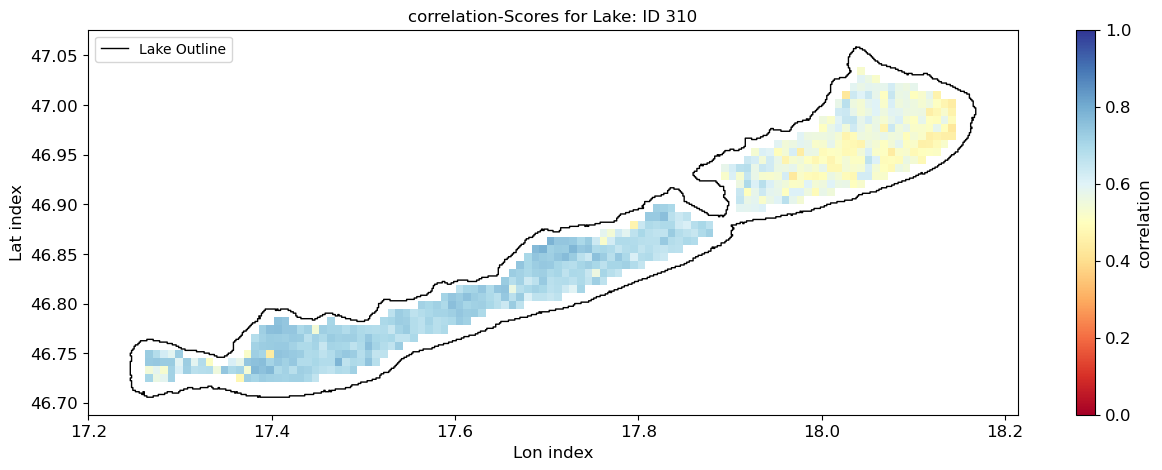

In [13]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(time_split = [[2002,2024]]),'correlation',fig,ax,'RdYlBu')

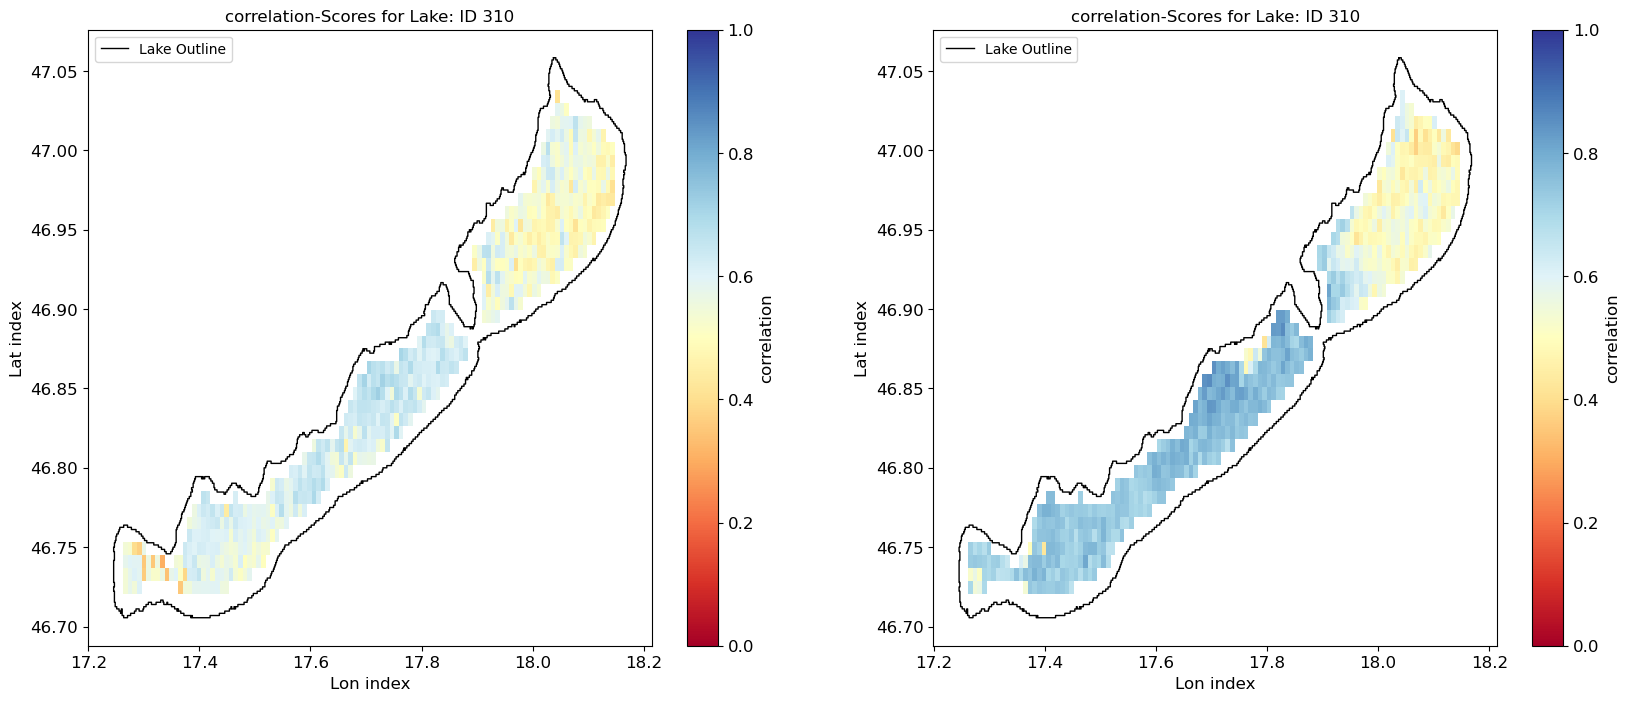

In [14]:
fig, axs = plt.subplots(1,2, figsize = (20,8))
cmap = 'RdYlBu'
colorbar_extent = [0,1]
phyco_v3.metric_map(phyco_v3.correlation_scores([(0, 2012)]),'correlation', fig, axs[0],cmap, colorbar_extent= colorbar_extent)
phyco_v3.metric_map(phyco_v3.correlation_scores([(2016,9999)]),'correlation', fig, axs[1],cmap, colorbar_extent= colorbar_extent)

# fig.axes[-1].remove()
# fig.axes[-1].remove()

# axs[0].set_xlabel('')
# axs[1].set_xlabel('')
# axs[0].set_ylabel('')
# axs[1].set_ylabel('')

# axs[1].set_yticklabels([])
# axs[0].get_legend().remove()
# axs[1].get_legend().remove()
# axs[0].set_title('')
# axs[1].set_title('')
# plt.tight_layout()

## Zoom in of peaks

with optional date highlighting

Used to compare against Mortimer's POLYMER processing

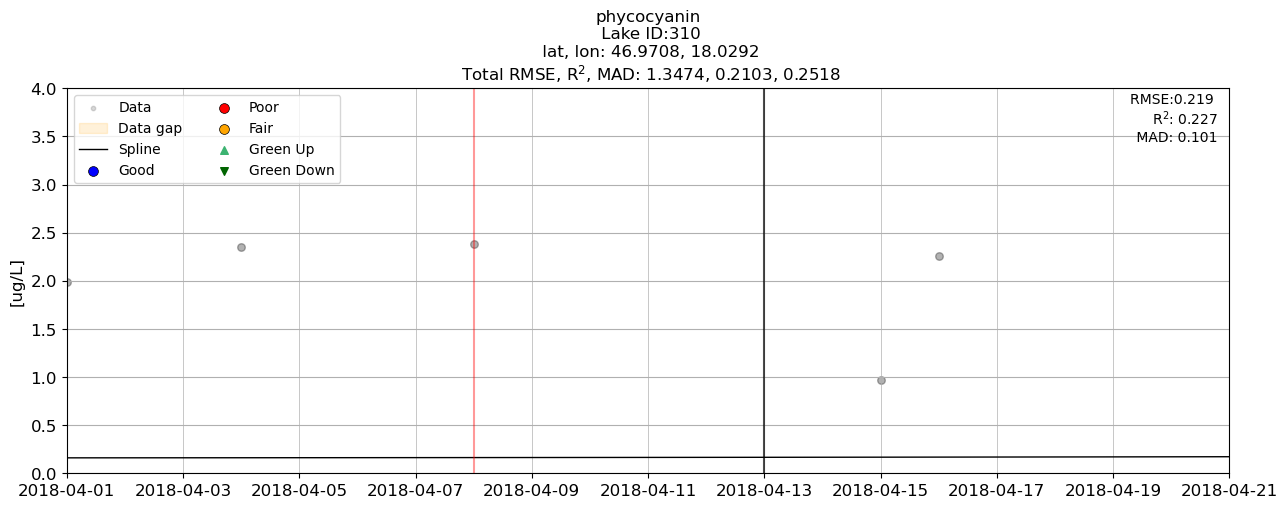

In [15]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

phyco_v3.single_plot(latitude_idx = i,longitude_idx = j, ax= ax, aggregation=True, start=2018, end= 2019)
ax.set_xlim(pd.to_datetime("01-04-2018", format= "%d-%m-%Y"), pd.to_datetime("21-04-2018", format= "%d-%m-%Y"))
ax.set_ylim(0,4)

ax.collections[0].set(color = 'black')
ax.collections[0].set_sizes([30])
ax.axvline(x=pd.to_datetime("08-04-2018", format= "%d-%m-%Y"),alpha = 0.4, c= "red")
ax.axvline(x=pd.to_datetime("13-04-2018", format= "%d-%m-%Y"),alpha = 0.7, c = "black")
# ax.axvline(x=pd.to_datetime("09-01-2022", format= "%d-%m-%Y"),alpha = 0.4, c= "purple")
# ax.axvline(x=pd.to_datetime("28-01-2022", format= "%d-%m-%Y"),alpha = 0.4, c= "purple")

## Single day plots

In [16]:
# manual_date = pd.to_datetime("06-11-2002", format= "%d-%m-%Y")
# print(manual_date)
# phyco_v3.single_day_map(manual_date)

In [17]:
series = phyco_v3.load_pixel_data(i, j)
for d in np.arange(-15,15):
    try:
        phyco_v3.single_day_map(manual_date+pd.Timedelta(d,"D"))
    except Exception:
        print(str(d)+": no data")

-15: no data
-14: no data
-13: no data
-12: no data
-11: no data
-10: no data
-9: no data
-8: no data
-7: no data
-6: no data
-5: no data
-4: no data
-3: no data
-2: no data
-1: no data
0: no data
1: no data
2: no data
3: no data
4: no data
5: no data
6: no data
7: no data
8: no data
9: no data
10: no data
11: no data
12: no data
13: no data
14: no data


## Sensor comparison plots

In [18]:
phyco_series = phyco_v3.load_pixel_data(i,j)
chla_series = chla_v3.load_pixel_data(i,j)
meris_sensor = chla_series.index.year < 2013

In [19]:
def sensor_str_from_year(year_val):
    if year_val < 2013:
        return "meris"
    elif year_val < 2016:
        return "modis"
    elif year_val >=2016:
        return "S3"

In [20]:
df_to_plot = pd.concat([chla_series,phyco_series],axis=1)
df_to_plot.columns = ['chla','phyco']
df_to_plot['phyco_chla'] = df_to_plot['phyco']/df_to_plot['chla']
df_to_plot['year'] = df_to_plot.index.year
df_to_plot['meris_period'] = df_to_plot['year'] < 2013
df_to_plot['sensor_period'] = df_to_plot['year'].apply(sensor_str_from_year)

In [21]:
default_cmap = sns.color_palette('tab10',3)
tri_order_cmap = [default_cmap[i] for i in [0,2,1]]
tri_order_cmap

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (1.0, 0.4980392156862745, 0.054901960784313725)]

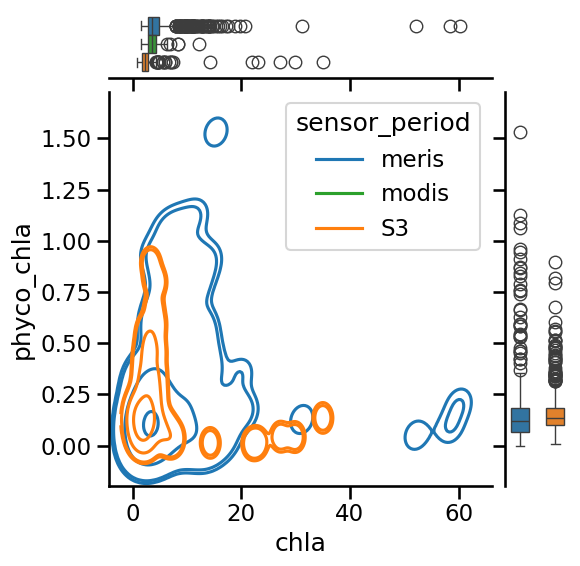

In [22]:
sns.set_context("talk")
g = sns.JointGrid(df_to_plot, x= "chla",y="phyco_chla",hue="sensor_period",hue_order=["meris","modis","S3"],height=6,palette=tri_order_cmap)
g.plot_joint(sns.kdeplot,levels=[0.005,0.01,0.1,0.5])
g.plot_marginals(sns.boxplot)

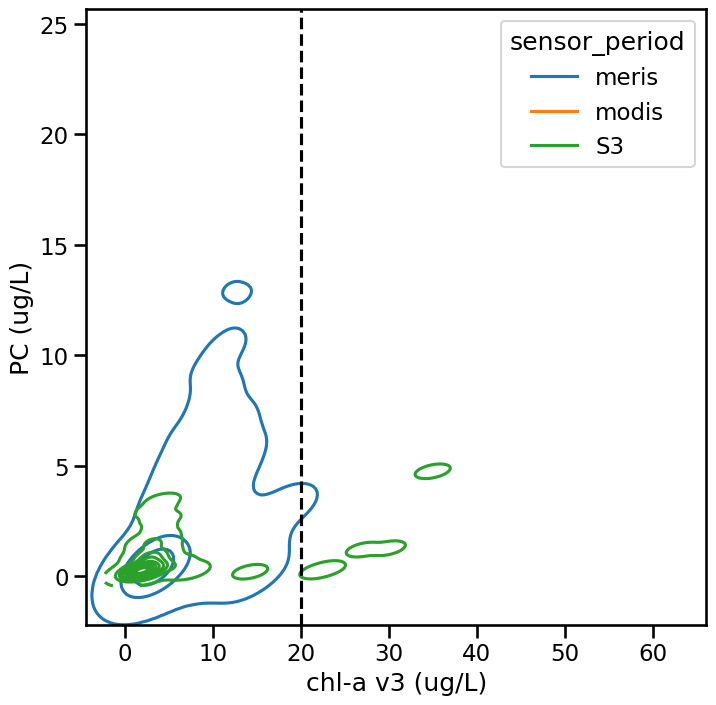

In [23]:
# Set up the figure
f, ax = plt.subplots(figsize=(8, 8))
sns.kdeplot(data=df_to_plot,x='chla',y='phyco',hue='sensor_period',levels=10,thresh=0.005)
plt.xlabel("chl-a v3 (ug/L)")
plt.ylabel("PC (ug/L)")
plt.axvline(20,c='k',linestyle='--')
# sns.move_legend(ax,'upper left')
# plt.xlim(right=150)
# plt.ylim(bottom=20)

In [24]:
chla_meris = df_to_plot.loc[df_to_plot['sensor_period']=='meris','chla']
chla_s3 = df_to_plot.loc[df_to_plot['sensor_period']=='S3','chla']

pd.concat([chla_meris.describe(), chla_s3.describe()],axis=1)



,chla,chla
count,506.000000,499.000000
mean,5.104214,2.619103
std,5.297342,2.756951
min,1.509174,0.798940
25%,2.850569,1.771187
50%,3.559018,2.195683
75%,4.766204,2.747911
max,60.194416,35.002472


## Panel of annual plots

In [25]:
year_vals = list(df_to_plot.index.year.unique())

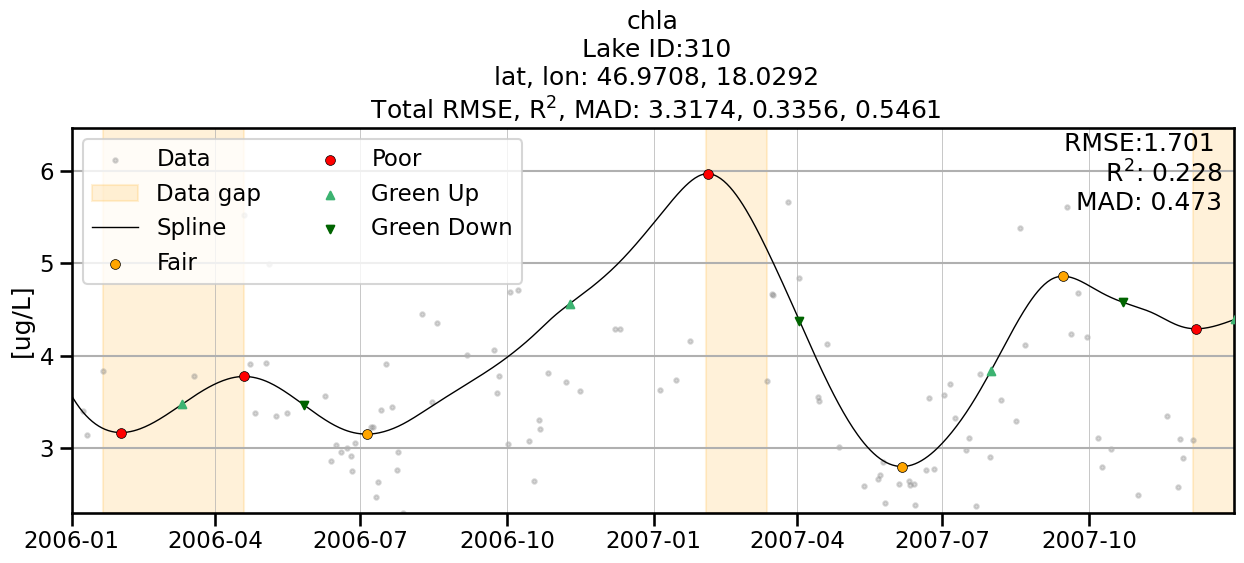

In [26]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(i,j, ax, aggregation=False,start=2006, end= 2007)

In [27]:
np.arange(2002,2004)

array([2002, 2003])

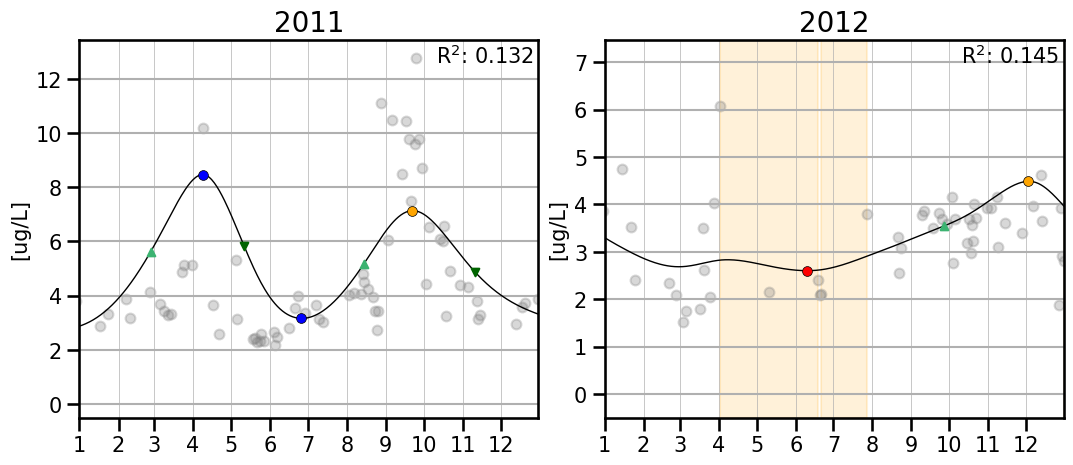

In [28]:
chla_v3.single_years_plot(i, j, np.arange(2011,2013), 4, 5,annotation= "R2")


## QA maps

In [29]:
p = netCDF4.Dataset(phyco_v3.p_path)

In [30]:
lats = p.variables["lat"][:]
lons = p.variables["lon"][:]
pks_qa = p['pks_qa']
trgs_qa = p['trgs_qa']

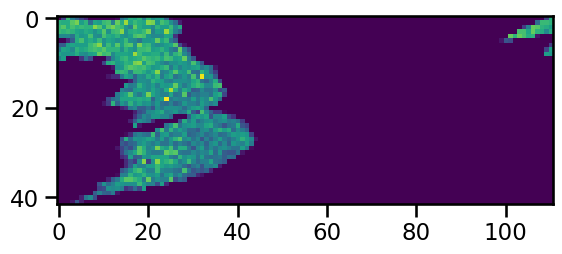

In [31]:
trgs_qa[:].shape
data = np.ma.masked_equal(trgs_qa[:], trgs_qa._FillValue)
counts_trgs = np.stack([
        np.sum(data == 0, axis=2),
        np.sum(data == 1, axis=2),
        np.sum(data == 2, axis=2)
    ], axis=2)
plt.imshow(counts_trgs[:,:,0])

In [32]:
def qa_counts_spatial(nc_var):
    data = nc_var[:]
    data = np.ma.masked_equal(data, nc_var._FillValue)

    counts = np.stack([
        np.sum(data == 0, axis=2),
        np.sum(data == 1, axis=2),
        np.sum(data == 2, axis=2)
    ], axis=2)
    return counts


In [33]:
counts_pks = qa_counts_spatial(p['pks_qa'])
counts_trgs = qa_counts_spatial(p['trgs_qa'])

In [34]:
def compute_qa_percentages_from_counts(counts):
    """
    Compute dataset-wide QA percentages from stacked counts.

    Parameters
    ----------
    counts : np.ndarray
        Array of shape (lat, lon, 3) with counts per category

    Returns
    -------
    dict
        Percentages for Good, Fair, Poor
    """

    # sum over all spatial dimensions
    totals_per_class = counts.sum(axis=(0, 1))  # shape (3,)

    total = totals_per_class.sum()

    if total == 0:
        return {"Good": np.nan, "Fair": np.nan, "Poor": np.nan}

    return {
        "Good": totals_per_class[0] / total * 100,
        "Fair": totals_per_class[1] / total * 100,
        "Poor": totals_per_class[2] / total * 100,
    }


In [35]:
def compute_lakewide_qa_percentages(nc_var):
    counts = qa_counts_spatial(nc_var)
    perc_dict = compute_qa_percentages_from_counts(counts)
    return perc_dict

In [36]:
compute_lakewide_qa_percentages(p['trgs_qa'])

{'Good': np.float64(54.39283344392833),
 'Fair': np.float64(24.193762441937626),
 'Poor': np.float64(21.413404114134043)}

In [37]:
compute_lakewide_qa_percentages(p['pks_qa'])

{'Good': np.float64(51.78630390279337),
 'Fair': np.float64(30.611503665059765),
 'Poor': np.float64(17.602192432146865)}

In [38]:
def plot_layers(
    data,
    lats,
    lons,
    titles=None,
    cmaps=None,
    vmin=None,
    vmax=None,
    mask_zero=False,
    figsize=(15, 5)
):
    """
    Generic multi-layer lat/lon plotting function.

    Parameters
    ----------
    data : np.ndarray
        Array of shape (lat, lon, n_layers)
    lats, lons : array-like
        Coordinates
    titles : list of str, optional
        Titles for each layer
    cmaps : list of str, optional
        Colormaps for each layer
    vmin, vmax : float, optional
        Color scale limits
    mask_zero : bool
        If True, mask zero values
    figsize : tuple
        Figure size
    """

    n_layers = data.shape[2]

    if titles is None:
        titles = [f"Layer {i}" for i in range(n_layers)]

    if cmaps is None:
        cmaps = ["viridis"] * n_layers

    if vmin is None:
        vmin = np.nanmin(data)
    if vmax is None:
        vmax = np.nanmax(data)

    fig, axes = plt.subplots(1, n_layers, figsize=figsize)

    # handle case: only one layer
    if n_layers == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        layer = data[:, :, i]

        if mask_zero:
            layer = np.ma.masked_where(layer == 0, layer)

        mesh = ax.pcolormesh(
            lons, lats, layer,
            shading="auto",
            cmap=cmaps[i],
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(titles[i])
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        plt.colorbar(mesh, ax=ax)

    plt.tight_layout()
    return fig, axes


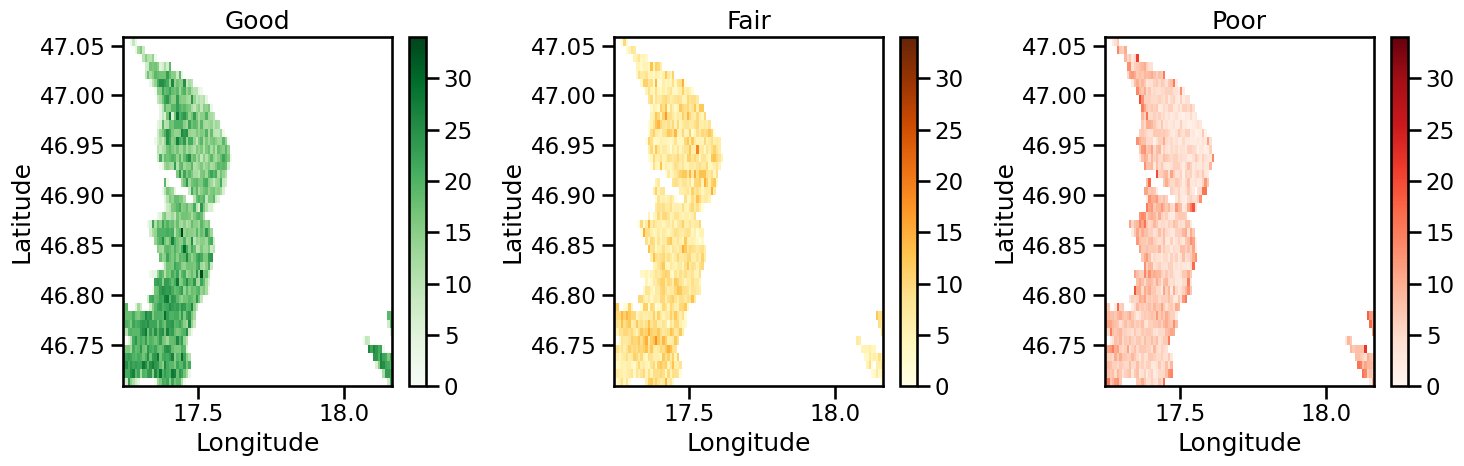

In [39]:
fig, axes = plot_layers(
    counts_trgs,
    lats,
    lons,
    titles=["Good", "Fair", "Poor"],
    cmaps=["Greens", "YlOrBr", "Reds"],
    mask_zero=True
)


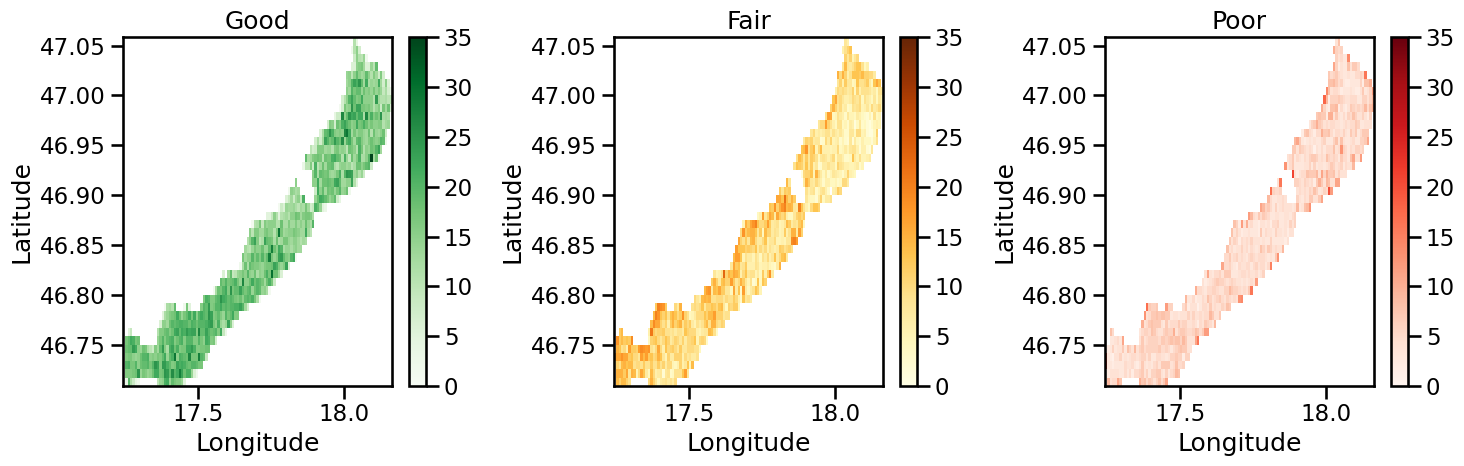

In [40]:
fig, axes = plot_layers(
    counts_pks,
    lats,
    lons,
    titles=["Good", "Fair", "Poor"],
    cmaps=["Greens", "YlOrBr", "Reds"],
    mask_zero=True
)


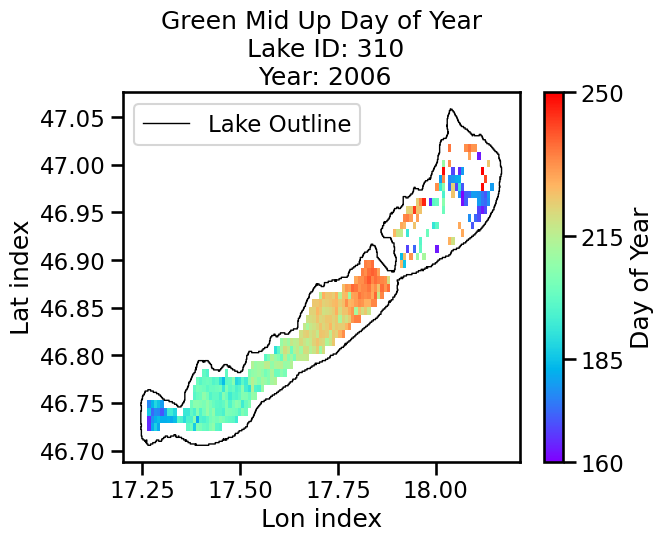

In [43]:
fig, ax = plt.subplots()
chla_v3.time_map(fig, ax, 2006, peaks=False, max = True, colorbar=True)